# S$^2$GT — Bivariate branching

A standard Shape Generalized Tree (SGT) routes each node with a shape function over one logical feature. **S$^2$GT** lets a node instead learn a shape function over a pair of logical features, so one interpretable node can represent interactions that require several univariate nodes. In `sgtlearn`, the opt-in **Shape²CART** training path learns these bivariate nodes.

> **When to use this.** Enable bivariate branching when validation data suggests that interactions matter and a univariate SGT needs extra depth to express them. It increases node-fitting cost, so start with a small candidate budget and compare against the default univariate model.

## What changes inside a node

The outer SGT is unchanged. The difference is the small inner model used to route one outer node:

1. Fit the best univariate shape function among the node's `max_features` subset.
2. Screen unordered pairs from that same subset and fully fit the best `pairwise_candidates` pairs.
3. For each retained pair, fit an ordinary **axis-aligned CART over two logical features**. These are not oblique splits.
4. Compare the best pair with the best univariate candidate after applying `pairwise_penalty` to pair selection.
5. Map the winning inner leaves to the node's `num_partitions` outer children.

A model with bivariate branching enabled may still choose a univariate node whenever it scores better. `pairwise_candidates=0` disables pair search and exactly preserves the default path.

## A three-way interaction in one node

This target has three nested regions: corners, an edge-cross, and a center square. Neither feature alone identifies all three classes, but their joint location does. We fit both classifiers at outer depth 1 so the comparison isolates the routing rule rather than added tree depth.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sgtlearn import SGTClassifier, plot_tree


def three_way_regions(X):
    inside_x = np.abs(X[:, 0]) < 0.85
    inside_y = np.abs(X[:, 1]) < 0.85
    return np.where(inside_x & inside_y, 2, np.where(inside_x | inside_y, 1, 0))


rng = np.random.default_rng(0)
X_train = rng.uniform(-2.5, 2.5, size=(2400, 2))
y_train = three_way_regions(X_train)

axis = np.linspace(-2.5, 2.5, 201)
x1, x2 = np.meshgrid(axis, axis)
X_grid = np.column_stack([x1.ravel(), x2.ravel()])
y_grid = three_way_regions(X_grid)

In [2]:
common = dict(
    max_depth=1,
    inner_max_depth=4,
    inner_max_leaf_nodes=9,
    num_partitions=3,
    tao_n_runs=0,  # compare the greedy routing rules directly
    random_state=0,
)

univariate = SGTClassifier(pairwise_candidates=0, **common).fit(X_train, y_train)
bivariate = SGTClassifier(pairwise_candidates=1, **common).fit(X_train, y_train)

print(f"Univariate SGT grid accuracy: {univariate.score(X_grid, y_grid):.3f}")
print(f"Bivariate S²GT grid accuracy: {bivariate.score(X_grid, y_grid):.3f}")

Univariate SGT grid accuracy: 0.660
Bivariate S²GT grid accuracy: 1.000


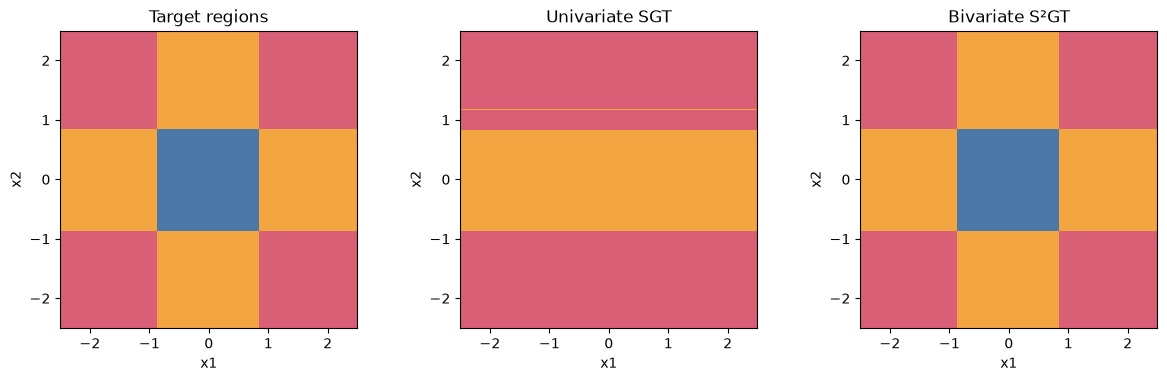

In [3]:
cmap = ListedColormap(["#d95f76", "#f2a541", "#4c78a8"])
predictions = [y_grid, univariate.predict(X_grid), bivariate.predict(X_grid)]
titles = ["Target regions", "Univariate SGT", "Bivariate S²GT"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), constrained_layout=True)
for ax, values, title in zip(axes, predictions, titles):
    ax.contourf(x1, x2, values.reshape(x1.shape), levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap)
    ax.set(title=title, xlabel="x1", ylabel="x2", aspect="equal")
plt.show()

The univariate root can carve repeated intervals along only one axis, so it cannot distinguish the center from both arms of the cross. The bivariate root combines thresholds from both axes and routes all three regions directly.

## Reading a bivariate node

`plot_tree` renders an S$^2$GT node as its exact two-dimensional routing heatmap. Colors identify outer branches. Numeric ticks mark thresholds where the final branch changes; redundant inner-CART thresholds are omitted. Passing `X` adds marginal histograms, and missing-value margins appear only for axes with missing observations.

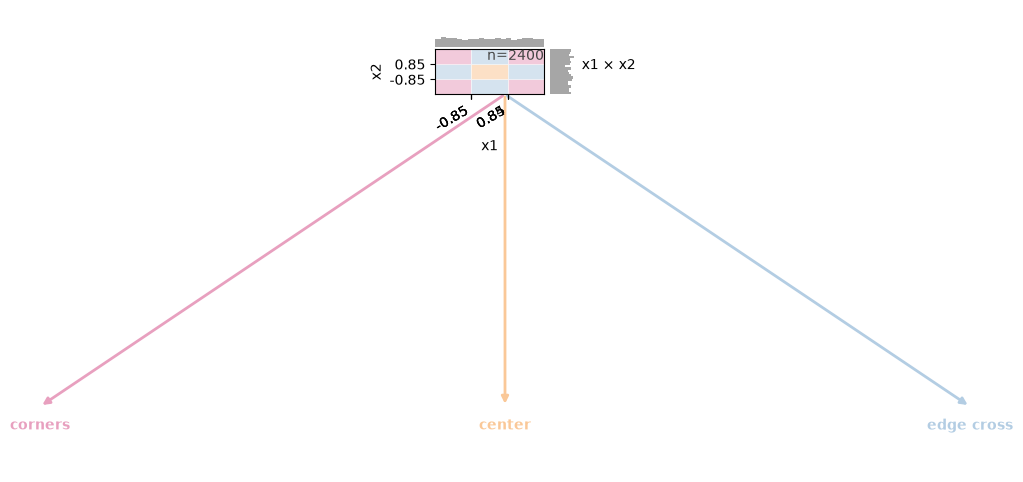

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(
    bivariate,
    X=X_train,
    feature_names=["x1", "x2"],
    class_names=["corners", "edge cross", "center"],
    precision=2,
    node_aspect_ratio=1.2,
    ax=ax,
)
plt.show()

## Tuning the pair search

Tune these controls on validation data and measure fit time as well as predictive performance:

| Parameter | Effect | Practical starting point |
| --- | --- | --- |
| `pairwise_candidates` | Enables pair search and limits how many screened pairs are fully fitted at each node. An integer is an absolute count; a float resolves to `ceil(value * n_logical_features)`. | Start with a small integer such as `1`–`5`; increase only if validation performance justifies the cost. |
| `pairwise_penalty` | Discourages selecting a pair over the best univariate candidate. It affects selection only, not raw-gain or minimum-leaf checks. | Start at `0`, then increase if pair nodes proliferate without improving validation performance. |
| `tao_pair_scale` | Multiplies `tao_lambda` for retained pair routers during TAO; the default is `1.1`. It does not reuse `pairwise_penalty`. | Keep `1.1` initially; tune it only when using regularized pair-aware TAO. |

`max_features` still chooses the logical-feature subset available at each node, so it also limits which pairs can be formed. `num_partitions` is independent: it sets the number of outgoing outer branches for either a univariate or bivariate router.

## Categorical and missing values

Pairs may be continuous×continuous, continuous×categorical, or categorical×categorical. One-hot columns grouped with `feature_dict` remain one logical categorical feature during pair screening.

Missing values are routed per feature rather than through one shared OR bin. For example, “`x1` is in this interval while `x2` is `NaN`” and “`x1` is `NaN` while `x2` is in this interval” are distinct inner bins, and a missing branch may continue splitting on the other feature. See [Categorical features](categorical-features.ipynb) for logical feature grouping.

## Feature importance and TAO

> **Warning**
>
> With `tao_n_runs=0`, a pair node's impurity gain is split equally between its two logical features for bookkeeping. That symmetric split is not a unique or fully trustworthy attribution of either feature's contribution. After any positive-run TAO refinement, impurity `feature_importances_` are unavailable for both univariate and bivariate models. Use held-out [permutation importance](feature-importance.ipynb) when reliable attribution matters.

TAO can revisit only the pairs retained during initial Shape²CART screening. Set `tao_n_runs=0` to inspect the original greedy tree, or leave TAO enabled and evaluate the refined model without impurity importances.

## Takeaways

- Leave `pairwise_candidates=0` for the default univariate SGT.
- Enable a small candidate budget when feature interactions may reduce outer-tree depth.
- Use `pairwise_penalty` to prefer simpler univariate routing when gains are close.
- Read pair nodes with `plot_tree`; the heatmap is the exact learned router, not a surrogate.
- Validate accuracy and runtime together.

S$^2$GT and Shape²CART extend the algorithms introduced in [Empowering Decision Trees via Shape Function Branching](https://neurips.cc/virtual/2025/loc/san-diego/poster/115950). See the [estimator API](../api/estimators.rst), [plotting API](../api/plotting.rst), and [TAO API](../api/tao.rst) for the complete parameter contracts.